__The RMS Titanic sank in the early morning hours of 15 April 1912 in the North Atlantic Ocean, four days into her maiden voyage from Southampton to New York City. The largest ocean liner in service at the time, Titanic had an estimated 2,224 people on board when she struck an iceberg at around 23:40 (ship's time) on Sunday, 14 April 1912. Her sinking two hours and forty minutes later at 02:20 (ship's time; 05:18 GMT) on Monday, 15 April, resulted in the deaths of more than 1,500 people, making it one of the deadliest peacetime maritime disasters in history.__

<img src="titanic.jpg" alt="Sinking of the Titanic" width="500" style="max-width: 100%; height: auto;">

In [3]:
# importing all required modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# disabling all warning messages coming
import warnings
warnings.filterwarnings("ignore")

In [5]:
df_survive=pd.read_csv(r"titanic_survive.csv")

In [6]:
df_survive.head()

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Exploring the data

* **PassengerID -** A column added to identify each row and make submissions easier
* **Survived -** Whether the passenger survived or not and the value we are predicting (0=No, 1=Yes)
* **Pclass -** The class of the ticket the passenger purchased (1=1st, 2=2nd, 3=3rd)
* **Name -** The passenger's name
* **Gender -** The passenger's gender
* **Age -** The passenger's age in years
* **SibSp -** The number of siblings or spouses the passenger had aboard the Titanic
* **Parch -** The number of parents or children the passenger had aboard the Titanic
* **Ticket -** The passenger's ticket number
* **Fare -** The fare the passenger paid
* **Cabin -** The passenger's cabin number
* **Embarked -** The port where the passenger embarked (on board) (C=Cherbourg, Q=Queenstown, S=Southampton)


In [7]:
df_survive.shape

(891, 12)

In [8]:
df_survive.isnull().head()

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False


<Axes: >

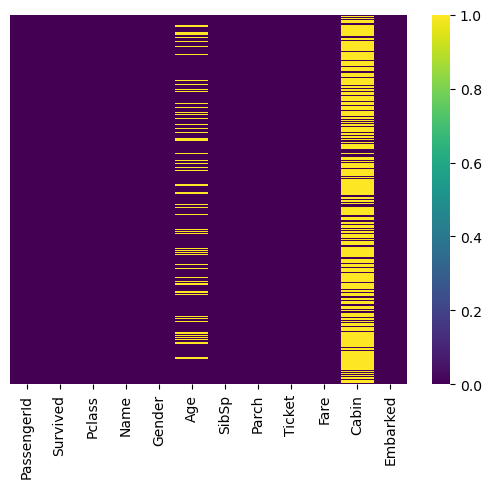

In [9]:
sns.heatmap(df_survive.isnull(), yticklabels = False, cbar = True, cmap = 'viridis')
# cbar : boolean, optional: Whether to draw a colorbar.
# new matplotlib default colormap (“viridis”) 

In [10]:
df_survive.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Gender       891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [11]:
df_survive.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Gender           0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [12]:
df_survive.corr(numeric_only = True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


<Axes: >

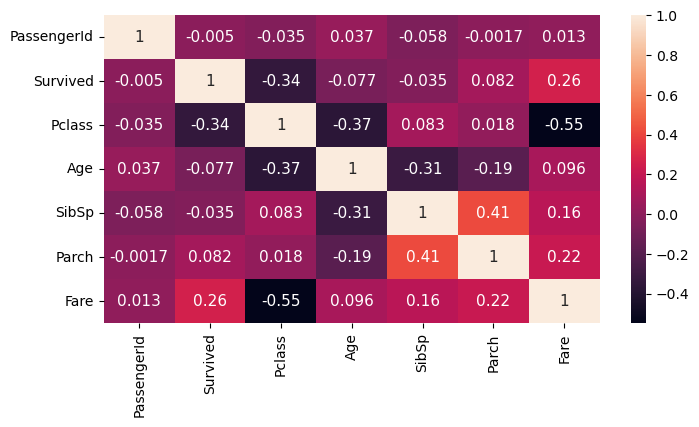

In [13]:
plt.figure(figsize = (8, 4))
sns.heatmap(df_survive.corr(numeric_only=True) , annot = True, annot_kws = {"size":11})

<Axes: xlabel='Survived', ylabel='count'>

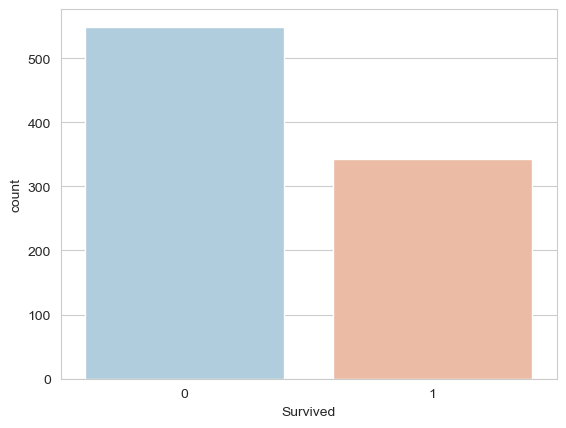

In [14]:
sns.set_style('whitegrid')
sns.countplot(x = 'Survived', data = df_survive, palette = 'RdBu_r')

In [15]:
print ("0 - Count =", len(df_survive[df_survive.Survived == 0]), end = ", ")
print ("1 - Count =", len(df_survive[df_survive.Survived == 1]), end = ", ")
print ("Total Count =", len(df_survive))

0 - Count = 549, 1 - Count = 342, Total Count = 891


In [16]:
print ("0 - Male =", len(df_survive[(df_survive.Survived == 0) & (df_survive.Gender == 'male')]), end = ", ")
print ("0 - Female =", len(df_survive[(df_survive.Survived == 0) & (df_survive.Gender == 'female')]), end = ", ")
print ("1 - Male =", len(df_survive[(df_survive.Survived == 1) & (df_survive.Gender == 'male')]), end = ", ")
print ("1 - Female =", len(df_survive[(df_survive.Survived == 1) & (df_survive.Gender == 'female')]), end = ", ")

0 - Male = 468, 0 - Female = 81, 1 - Male = 109, 1 - Female = 233, 

<Axes: xlabel='Survived', ylabel='count'>

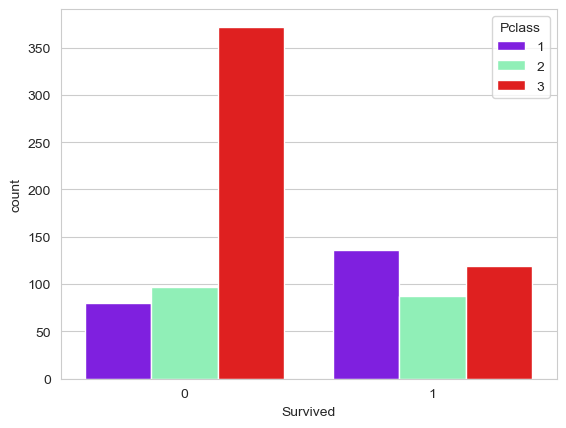

In [17]:
sns.set_style('whitegrid')
sns.countplot(x = 'Survived', hue = 'Pclass', data = df_survive, palette = 'rainbow')

In [18]:
print ("0 - Pclass-1 =", len(df_survive[(df_survive.Survived == 0) & (df_survive.Pclass == 1)]), end = ", ")
print ("0 - Pclass-2 =", len(df_survive[(df_survive.Survived == 0) & (df_survive.Pclass == 2)]), end = ", ")
print ("0 - Pclass-3 =", len(df_survive[(df_survive.Survived == 0) & (df_survive.Pclass == 3)]), end = ", ")
print ("1 - Pclass-1 =", len(df_survive[(df_survive.Survived == 1) & (df_survive.Pclass == 1)]), end = ", ")
print ("1 - Pclass-2 =", len(df_survive[(df_survive.Survived == 1) & (df_survive.Pclass == 2)]), end = ", ")
print ("1 - Pclass-3 =", len(df_survive[(df_survive.Survived == 1) & (df_survive.Pclass == 3)]), end = ", ")

0 - Pclass-1 = 80, 0 - Pclass-2 = 97, 0 - Pclass-3 = 372, 1 - Pclass-1 = 136, 1 - Pclass-2 = 87, 1 - Pclass-3 = 119, 

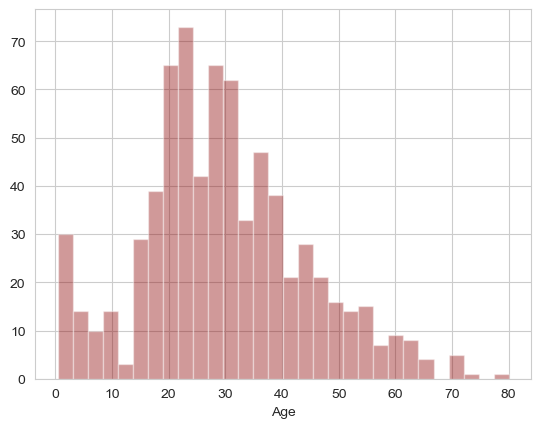

In [27]:
sns.distplot(df_survive['Age'].dropna(), kde = False, color = 'darkred', bins = 30);
# kde : bool, optional, whether to plot a gaussian kernel density estimate.
# bins denotes number of class intervals

<Axes: xlabel='SibSp', ylabel='count'>

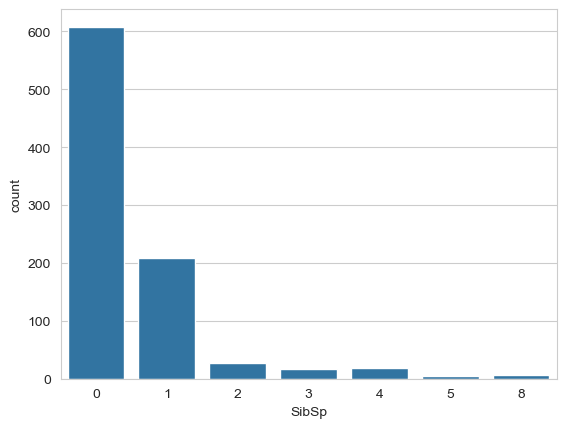

In [28]:
sns.countplot(x = 'SibSp', data = df_survive)

<Axes: >

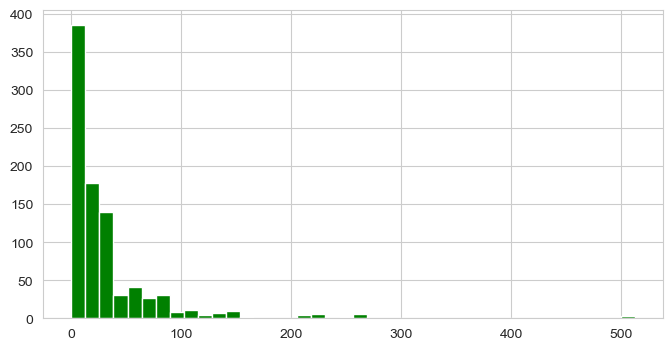

In [29]:
df_survive['Fare'].hist(color = 'green', bins = 40, figsize = (8, 4))

<Axes: xlabel='Pclass', ylabel='Age'>

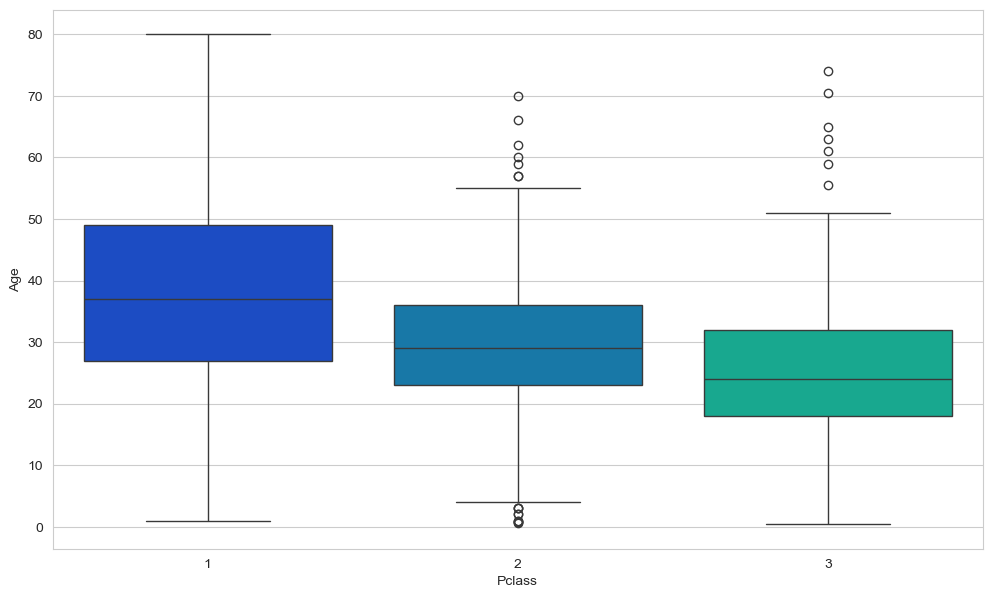

In [30]:
plt.figure(figsize = (12, 7))
sns.boxplot(x = 'Pclass', y = 'Age', data = df_survive, palette = 'winter')

In [31]:
print ("Median of age for Pclass-1 =", np.median(df_survive[df_survive.Pclass == 1][['Age']].dropna()), end = ", ")
print ("Plass-2 =", np.median(df_survive[df_survive.Pclass == 2][['Age']].dropna()), end = ", ")
print ("and Pclass-3 =", np.median(df_survive[df_survive.Pclass == 3][['Age']].dropna()), end = ", ")

Median of age for Pclass-1 = 37.0, Plass-2 = 29.0, and Pclass-3 = 24.0, 

In [32]:
def impute_age(cols):    # cols is a series object with two labeled values: Age and Pclass with index values 0 and 1 respectively
    Age = cols[0]
    Pclass = cols[1]
    
    if pd.isnull(Age):
        if Pclass == 1: return 37      # Median value for Pclass-1
        elif Pclass == 2: return 29    # Median value for Pclass-2
        else: return 24                # Median value for Pclass-3
    else:
        return Age                     # If Age is not null

In [33]:
df_survive.head(n = 10)

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [34]:
df_survive['Age'] = df_survive[['Age', 'Pclass']].apply(impute_age, axis = 1)
df_survive.head(n = 10)

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,24.0,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


<Axes: >

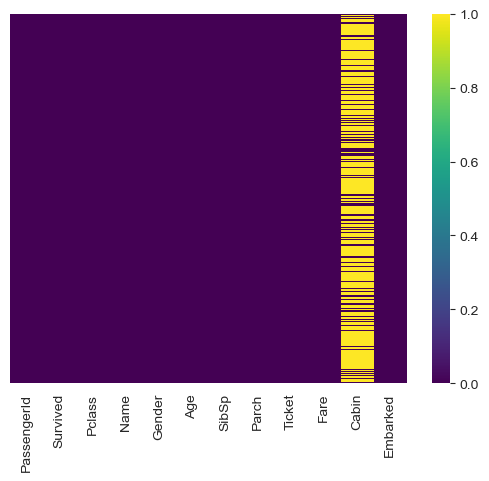

In [35]:
sns.heatmap(df_survive.isnull(), yticklabels = False, cbar = True, cmap = 'viridis')

In [36]:
df_survive.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Gender           0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [37]:
df_survive.drop('Cabin', inplace = True, axis = 1)

In [43]:
print("Remain columns:\n", df_survive.columns)
print("Shape of the DataFrame:", df_survive.shape)
print("Null values:")
print(df_survive.isnull().sum())

Remain columns:
 Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Gender', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')
Shape of the DataFrame: (891, 11)
Null values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Gender         0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64


In [44]:
# locating a data point with a null value at Embarked column
print(df_survive[['PassengerId', 'Survived', 'Pclass', 'Embarked']][60:63])
# df_survive.dropna(inplace = True)

print (df_survive.Embarked.value_counts())
most_frequent_value = df_survive.Embarked.mode()[0]
print (f"Most frequent Embarked value is {most_frequent_value}")

# fill null values in Embarked column with the most frequent value of Embarked column
df_survive.Embarked = df_survive.Embarked.fillna(value = most_frequent_value)

print(df_survive[['PassengerId', 'Survived', 'Pclass', 'Embarked']][60:63])

    PassengerId  Survived  Pclass Embarked
60           61         0       3        C
61           62         1       1      NaN
62           63         0       1        S
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64
Most frequent Embarked value is S
    PassengerId  Survived  Pclass Embarked
60           61         0       3        C
61           62         1       1        S
62           63         0       1        S


In [46]:
df_survive.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Gender         0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [47]:
gender = pd.get_dummies(df_survive['Gender'])
gender.head()

,female,male
0,False,True
1,True,False
2,True,False
3,True,False
4,False,True


In [48]:
# Convert categorical variable into dummy/indicator variables
gender = pd.get_dummies(df_survive['Gender'], drop_first = True)

print(df_survive['Gender'].head())
print("gender -> \n", gender.head())

0      male
1    female
2    female
3    female
4      male
Name: Gender, dtype: object
gender -> 
     male
0   True
1  False
2  False
3  False
4   True


In [49]:
embark = pd.get_dummies(df_survive['Embarked'])
embark.head()

,C,Q,S
0,False,False,True
1,True,False,False
2,False,False,True
3,False,False,True
4,False,False,True


In [50]:
# Convert categorical variable into dummy/indicator variables
embark = pd.get_dummies(df_survive['Embarked'], drop_first = True)

print(df_survive['Embarked'].head())
print("embark -> \n",embark.head())

0    S
1    C
2    S
3    S
4    S
Name: Embarked, dtype: object
embark -> 
        Q      S
0  False   True
1  False  False
2  False   True
3  False   True
4  False   True


In [51]:
df_survive.drop(['Gender', 'Embarked', 'Name', 'Ticket'], axis = 1, inplace = True)

In [52]:
print (df_survive.shape, type(df_survive))
df_survive.head()

(891, 7) <class 'pandas.core.frame.DataFrame'>


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500


## Survival Prediction Model

In [53]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(df_survive.drop('Survived', axis = 1), df_survive['Survived'],
                                               test_size = 0.30, random_state = 100)
print("No. of Train rows -> ", y_train.shape, x_train.shape)
print("No. of Test rows -> ", y_test.shape, x_test.shape)

No. of Train rows ->  (623,) (623, 6)
No. of Test rows ->  (268,) (268, 6)


In [54]:
from sklearn.linear_model import LogisticRegression
logmodel = LogisticRegression(max_iter=500)
logmodel

LogisticRegression(max_iter=500)

In [55]:
logmodel.fit(x_train, y_train)

LogisticRegression(max_iter=500)

In [56]:
predictions = logmodel.predict(x_test)
print (predictions.shape)
predictions

(268,)


array([0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 0], dtype=int64)

In [58]:
from sklearn.metrics import classification_report
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.70      0.91      0.79       159
           1       0.77      0.44      0.56       109

    accuracy                           0.72       268
   macro avg       0.74      0.68      0.68       268
weighted avg       0.73      0.72      0.70       268



[[145  14]
 [ 61  48]]


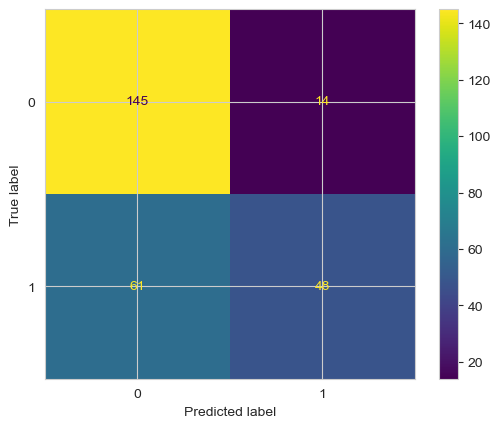

In [68]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cm=confusion_matrix(y_test, predictions)
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logmodel.classes_)
disp.plot()


In [63]:
confusion_df = pd.DataFrame(confusion_matrix(y_test, predictions),
             columns = ["Predicted Class " + str(class_name) for class_name in [0, 1]],
             index = ["Actual Class " + str(class_name) for class_name in [0, 1]])

confusion_df

,Predicted Class 0,Predicted Class 1
Actual Class 0,145,14
Actual Class 1,61,48


In [70]:
print("Cofefficients -> \n", logmodel.coef_)
print("Intercept -> ", logmodel.intercept_)

Cofefficients -> 
 [[-1.48306970e-04 -9.65457806e-01 -3.69255500e-02 -1.57206813e-01
   1.09435688e-01  4.19374750e-03]]
Intercept ->  [2.69782291]


fpr: [0.         0.08805031 1.        ]
tpr: [0.         0.44036697 1.        ]
threshold: [inf  1.  0.]
AUC Score: 0.6761583290058277


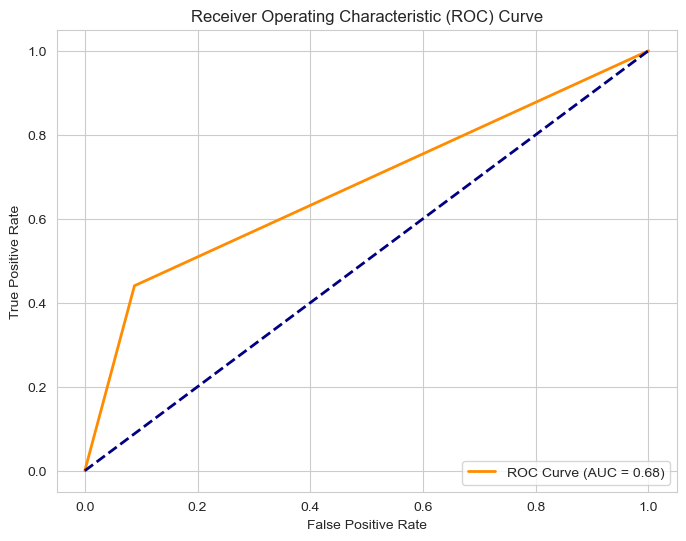

In [71]:
from sklearn.metrics import roc_curve, auc, roc_auc_score


# Compute FPR, TPR and threshold values
fpr, tpr, thresholds = roc_curve(y_test, predictions)
print("fpr:", fpr)
print("tpr:", tpr)
print("threshold:", thresholds)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Print AUC Score
print("AUC Score:", roc_auc)

# Plotting ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC Curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()